<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_17_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
veri = pd.read_csv("/content/ikinci_el_telefon.csv")

In [8]:
veri.head()

,marka,model,il,depolama_gb,ram_gb,cihaz_yasi_ay,pil_sagligi,kozmetik_durum,ekran_degisti,kutu_fatura,garanti_devam,satici_tipi,fiyat
0,Xiaomi,Redmi Note 11,Kocaeli,256,4,22,83,Orta,0,1,1,Magaza,7350
1,Samsung,Galaxy S21,Giresun,128,8,34,80,Iyi,0,0,0,Bireysel,24250
2,Xiaomi,Xiaomi 13T,Balikesir,256,12,30,78,Iyi,0,0,0,Bireysel,18550
3,Samsung,Galaxy A15,Kocaeli,128,4,21,85,Kusursuz,0,0,1,Bireysel,7750
4,Apple,iPhone 12 Mini,Ordu,128,4,47,73,Kusursuz,0,0,0,Bireysel,20000


In [10]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   marka           40000 non-null  object
 1   model           40000 non-null  object
 2   il              40000 non-null  object
 3   depolama_gb     40000 non-null  int64 
 4   ram_gb          40000 non-null  int64 
 5   cihaz_yasi_ay   40000 non-null  int64 
 6   pil_sagligi     40000 non-null  int64 
 7   kozmetik_durum  40000 non-null  object
 8   ekran_degisti   40000 non-null  int64 
 9   kutu_fatura     40000 non-null  int64 
 10  garanti_devam   40000 non-null  int64 
 11  satici_tipi     40000 non-null  object
 12  fiyat           40000 non-null  int64 
dtypes: int64(8), object(5)
memory usage: 4.0+ MB


In [12]:
veri.shape

(40000, 13)

In [14]:
veri.describe()

,depolama_gb,ram_gb,cihaz_yasi_ay,pil_sagligi,ekran_degisti,kutu_fatura,garanti_devam,fiyat
count,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,196.233600,6.65200,28.432200,83.297175,0.089225,0.425300,0.376600,29240.687500
std,125.198459,2.22302,15.804512,7.994552,0.285072,0.494395,0.484539,23800.584903
min,64.000000,4.00000,5.000000,60.000000,0.000000,0.000000,0.000000,2000.000000
25%,128.000000,4.00000,16.000000,79.000000,0.000000,0.000000,0.000000,11850.000000
50%,128.000000,6.00000,26.000000,84.000000,0.000000,0.000000,0.000000,21550.000000
75%,256.000000,8.00000,38.000000,89.000000,0.000000,1.000000,1.000000,39600.000000
max,512.000000,12.00000,90.000000,98.000000,1.000000,1.000000,1.000000,190550.000000


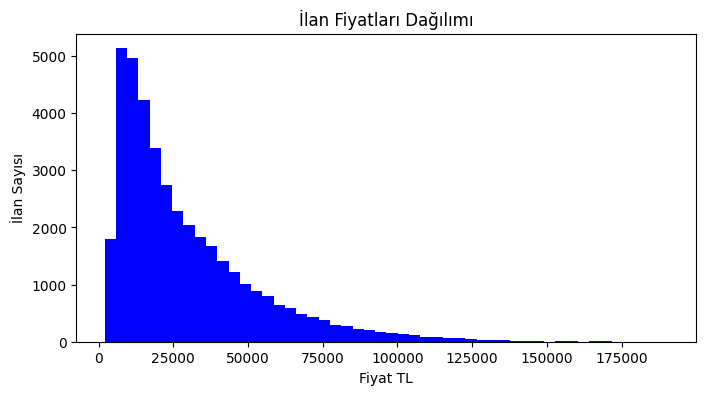

In [18]:
# histogram veya bar - fiyatlar ve ilan sayısı.
plt.figure(figsize=(8,4))
plt.hist(veri['fiyat'], bins=50, color="b")
plt.title("İlan Fiyatları Dağılımı")
plt.xlabel("Fiyat TL")
plt.ylabel("İlan Sayısı")
plt.show()

In [21]:
kategorik = ["marka","model","il","kozmetik_durum","satici_tipi"]
print(veri[kategorik].nunique())

marka              9
model             60
il                81
kozmetik_durum     4
satici_tipi        2
dtype: int64


In [23]:
print("En çok ilan olan iller:")
print(veri["il"].value_counts().head(5))

En çok ilan olan iller:
il
Istanbul    7205
Ankara      2664
Izmir       2129
Bursa       1459
Antalya     1275
Name: count, dtype: int64


In [25]:
print("En az ilan olan iller:")
print(veri["il"].value_counts().tail(5))

En az ilan olan iller:
il
Kilis        80
Gumushane    46
Ardahan      36
Tunceli      36
Bayburt      33
Name: count, dtype: int64


In [30]:
#modellerin fiyat ortalamaları - en ucuz 5 model, en pahalı 5 model. (groupby)
model_fiyat = veri.groupby("model")["fiyat"].mean().round().sort_values()
print("En Ucuz 5 model:")
print(model_fiyat.head(5))
print()
print("En Pahalı 5 model:")
print(model_fiyat.tail(5))



En Ucuz 5 model:
model
Tecno Spark 10    4228.0
Realme C55        5376.0
Redmi 13          6167.0
Tecno Camon 20    6423.0
Galaxy A14        6704.0
Name: fiyat, dtype: float64

En Pahalı 5 model:
model
Galaxy S24 Ultra      74282.0
iPhone 16             74931.0
iPhone 15 Pro         75016.0
iPhone 15 Pro Max     76425.0
iPhone 16 Pro        105666.0
Name: fiyat, dtype: float64


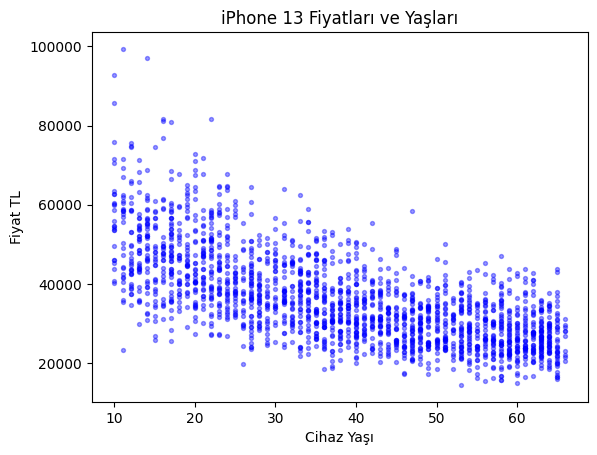

In [36]:
# model seçin, bu modelin cihaz yaşı ile fiyatını içeren bir scatter

iphone13 = veri[veri["model"] == "iPhone 13"]

plt.scatter(iphone13["cihaz_yasi_ay"], iphone13["fiyat"], color="b", s=8, alpha=0.4)
plt.title("iPhone 13 Fiyatları ve Yaşları")
plt.xlabel("Cihaz Yaşı")
plt.ylabel("Fiyat TL")
plt.show()

In [39]:
#groupby ile kozmetik durum fiyat ortalaması ilişkisi

kozmetik_fiyat = veri.groupby("kozmetik_durum")["fiyat"].mean().round().sort_values()
print(kozmetik_fiyat)

kozmetik_durum
Kotu        22012.0
Orta        26348.0
Iyi         30043.0
Kusursuz    31914.0
Name: fiyat, dtype: float64


In [ ]:
# Modelimize Hazırlık